# Objective
The objective of this analysis is to evaluate vendor performance across key business dimensions :sales contribution, profitability,and inventory efficiency in order to:

- Identify high and low performing vendors based on revenue and profit contribution
- Assess dependency on a limited set of vendors and highlight concentration risks
- Evaluate whether sales performance aligns with profitability (Hypothesis Testing)
- Detect vendors with untapped potential for procurement expansion
- Segment vendors into actionable priority groups using operational metrics (revenue, gross margin, sell-through, and unsold inventory)

This enables data-driven decision making for vendor selection, procurement planning, and portfolio optimization, ultimately improving both profitability and inventory health.

### Importing libraries

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sqlalchemy import create_engine,text
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

### Connection setup and Reading required datasets

In [2]:
# load env file and import credentials
load_dotenv()
DB_USER = os.getenv("DB_USER")
DB_HOST = os.getenv("DB_HOST")
DB_PASSWORD = os.getenv("DB_PASSWORD")

# establish connection to the 'inventory_db' database
conn_url = URL.create (
    drivername = "mysql+pymysql",
    host = DB_HOST,
    username = DB_USER,
    password = DB_PASSWORD,
    database = 'inventory_db'
)
conn_eng = create_engine(conn_url)
print("Connection Open to 'inventory_db' database")

Connection Open to 'inventory_db' database


In [3]:
# reading required tables from the database
with conn_eng.connect() as conn:
    dataset = pd.read_sql(text("select * from product_summary;"), conn)
    begin_inv = pd.read_sql(text('''select ProductId,sum(onHand) as BeginningInv
                                    from begin_inventory
                                    group by ProductId'''),conn)
print("(Rows, Columns) :",dataset.shape)
dataset.head(3)

(Rows, Columns) : (10485, 14)


,ProductId,Description,VendorNumber,VendorName,Volume_ml,ActualPrice,PurchasePrice,TotalQuantityPurchased,TotalPurchaseDollars,SalesPrice,TotalQuantitySold,TotalSalesDollars,GrossProfit,GrossProfitMargin
0,58,Gekkeikan Black & Gold Sake,8320,SHAW ROSS INT L IMP LTD,750,12.99,9.28,3550,32944.0,12.58,3446,43341.54,11362.66,26.22
1,62,Herradura Silver Tequila,1128,BROWN-FORMAN CORP,750,36.99,28.67,3200,91744.0,38.36,3125,119863.75,30270.00,25.25
2,63,Herradura Reposado Tequila,1128,BROWN-FORMAN CORP,750,38.99,30.46,2855,86963.3,40.41,2778,112249.22,27631.34,24.62


In [4]:
# Data enrichment
dataset = dataset.merge(begin_inv, on='ProductId', how='left')

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10485 entries, 0 to 10484
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProductId               10485 non-null  int64  
 1   Description             10485 non-null  object 
 2   VendorNumber            10485 non-null  int64  
 3   VendorName              10485 non-null  object 
 4   Volume_ml               10485 non-null  int64  
 5   ActualPrice             10485 non-null  float64
 6   PurchasePrice           10485 non-null  float64
 7   TotalQuantityPurchased  10485 non-null  int64  
 8   TotalPurchaseDollars    10485 non-null  float64
 9   SalesPrice              10485 non-null  float64
 10  TotalQuantitySold       10485 non-null  int64  
 11  TotalSalesDollars       10485 non-null  float64
 12  GrossProfit             10485 non-null  float64
 13  GrossProfitMargin       10485 non-null  float64
 14  BeginningInv            7272 non-null 

### Data Preparation

In [5]:
# Preparing summary dataset for analysis
vendor_summary = dataset.groupby(['VendorNumber','VendorName']).agg({
                    'PurchasePrice': 'median',
                    'TotalPurchaseDollars':'sum',
                    'TotalSalesDollars':'sum',
                    'GrossProfit':'sum',
                    'TotalQuantityPurchased':'sum',
                    'TotalQuantitySold':'sum',
                    'BeginningInv' : 'sum'
                }).reset_index()
vendor_summary.head(2)

,VendorNumber,VendorName,PurchasePrice,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,TotalQuantityPurchased,TotalQuantitySold,BeginningInv
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",20.430,5647.88,2739.99,899.51,329,101,16.0
1,60,ADAMBA IMPORTS INTL INC,13.855,76703.65,67576.22,3081.17,4726,3978,10.0


In [6]:
# Calculated Columns for deeper analysis

# Gross Profit Margin = Gross Profit*100/ Total Revenue
vendor_summary['GrossProfitMargin'] = (vendor_summary['GrossProfit']*100 /vendor_summary['TotalSalesDollars']).round(2)

# Sell Through Ratio = Sold Qty/ Available Qty
vendor_summary['SellThroughRatio']=(vendor_summary['TotalQuantitySold']/
                                (vendor_summary['TotalQuantityPurchased']+vendor_summary['BeginningInv'])).round(2)


In [7]:
# user defined function to format currency values
def format_currency(value):
    if abs(value) >= 1000_000:
        return f"${round(value/1000_000,2)}M"
    elif abs(value) >= 1000:
        return f"${round(value/1000,2)}K"
    else:
        return f"${round(value,2)}"

#### Top and Bottom performing Vendors by Sales

In [8]:
# Top 10 vendors by total sales
top10_vendors = vendor_summary[['VendorName','TotalSalesDollars']].sort_values(
                        by='TotalSalesDollars',ascending=False,ignore_index=True ).head(10)

# Bottom 10 vendors by total sales
bottom10_vendors = vendor_summary[['VendorName','TotalSalesDollars']].sort_values(
                        by='TotalSalesDollars',ignore_index=True ).head(10)

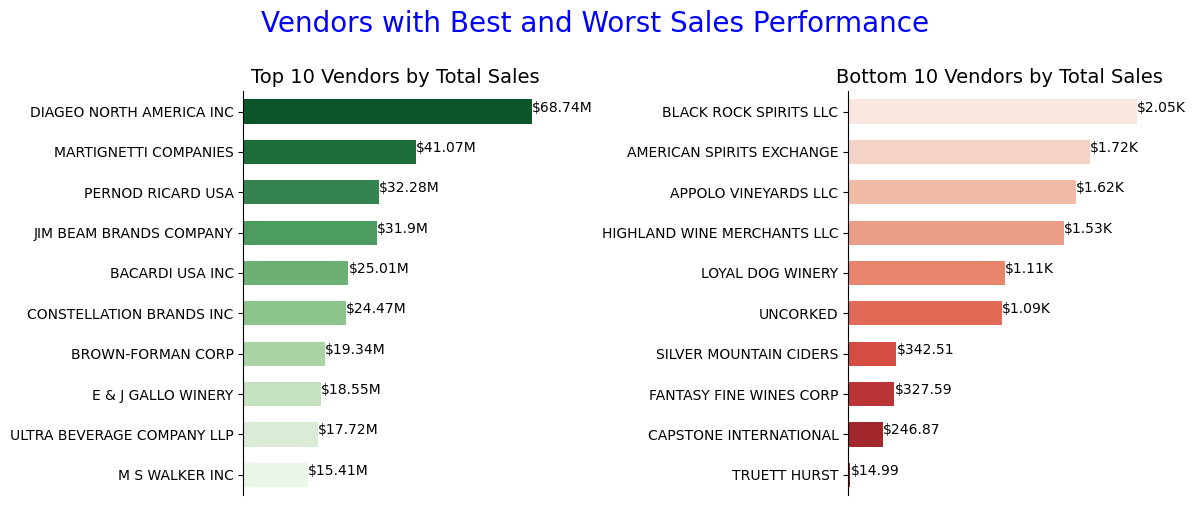

In [9]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
sns.barplot(data=top10_vendors,x='TotalSalesDollars',y='VendorName',
            hue='VendorName',palette='Greens_r',width=0.6, ax=ax[0])
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].set_xticks([])
ax[0].set_title('Top 10 Vendors by Total Sales',fontsize=14)
for i,txt in enumerate(top10_vendors['TotalSalesDollars']):
    ax[0].text(txt,i,format_currency(txt))

sns.barplot(data=bottom10_vendors,x='TotalSalesDollars',y='VendorName' ,
            hue='VendorName',palette='Reds_r', width=0.6, ax=ax[1])
ax[1].set_ylabel('')
ax[1].set_xlabel('')
ax[1].set_xticks([])
ax[1].invert_yaxis()
ax[1].set_title('Bottom 10 Vendors by Total Sales',fontsize=14)
for i,txt in enumerate(bottom10_vendors['TotalSalesDollars']):
    ax[1].text(txt,i,format_currency(txt))

plt.suptitle("Vendors with Best and Worst Sales Performance",fontsize=20,color='blue',y=1)
sns.despine(left=False,bottom=True)
plt.tight_layout()
plt.show()

In [12]:
# Revenue Concentration among top peforming vendors
vendor_summary['SalesContribution'] = (vendor_summary['TotalSalesDollars']*100/
                                        vendor_summary['TotalSalesDollars'].sum()).round(2)

# Pareto Rule check
n= int(dataset['VendorName'].nunique()*0.2)
print(f"Top 20% Vendors by Sales contribute {(round(
    vendor_summary['SalesContribution'].nlargest(n).sum(),2))}% of Total Sales.")

Top 20% Vendors by Sales contribute 88.44% of Total Sales.


> - Top performing vendors represent strategic partnerships and should be prioritized for retention, negotiations, and joint growth initiatives.

> - Bottom performing vendors contribute minimal revenue, indicating potential inefficiencies such as low demand, poor assortment, or ineffective pricing.

> - Revenue is highly concentrated among the top vendors, indicating strong dependence on a limited vendor base.

#### Top 20% Vendors by Profit Contribution (Pareto Rule check)  
i.e. Top vendor contribution analysis to assess profit dependency and concentration risk

In [13]:
vendor_summary['ProfitContribution'] = (vendor_summary['GrossProfit']*100/
                                        vendor_summary['GrossProfit'].sum()).round(2)

n = int(dataset['VendorName'].nunique()*0.2)
profit_vendors = vendor_summary[['VendorName','ProfitContribution']].sort_values(
                        by='ProfitContribution',ascending=False,ignore_index=True
                        ).head(n)

profit_vendors.head(5)

,VendorName,ProfitContribution
0,DIAGEO NORTH AMERICA INC,13.55
1,MARTIGNETTI COMPANIES,10.15
2,CONSTELLATION BRANDS INC,6.59
3,PERNOD RICARD USA,6.29
4,JIM BEAM BRANDS COMPANY,6.18


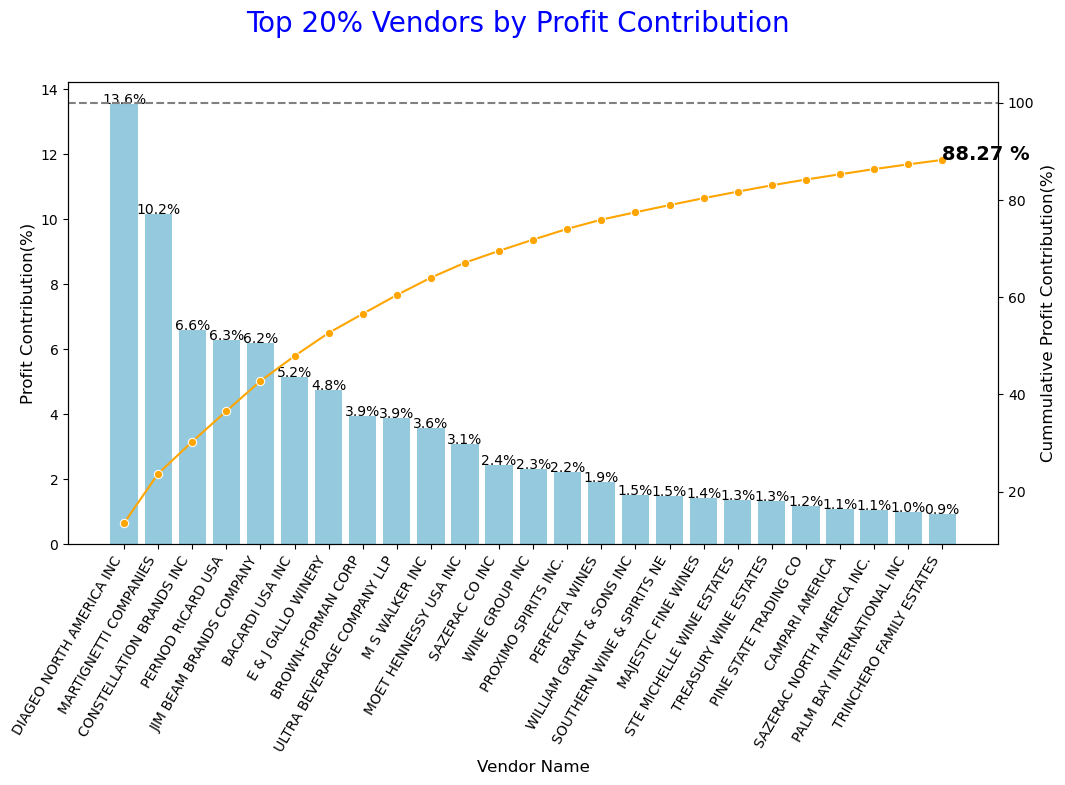

In [14]:
fig,ax1=plt.subplots(figsize=(12,6))
sns.barplot(data=profit_vendors, x='VendorName', y='ProfitContribution', color='skyblue', ax=ax1)
for i,txt in enumerate(profit_vendors['ProfitContribution']):
    ax1.text(i, txt, f'{round(txt,1)}%', ha='center')

ax2 = ax1.twinx()
sns.lineplot(data=profit_vendors['ProfitContribution'].cumsum(),color='orange',marker='o',ax=ax2)
ax2.text(len(profit_vendors)-1, profit_vendors['ProfitContribution'].sum(),
         f'{round(profit_vendors['ProfitContribution'].sum(),2)} %',
         fontweight='bold', fontsize=14)

ax2.axhline(100, color='gray', linestyle='--')
ax2.set_ylabel('Cummulative Profit Contribution(%)', fontsize=12)
ax1.set_xticks(range(len(profit_vendors)))
ax1.set_xticklabels(profit_vendors['VendorName'], rotation=60, ha='right')
ax1.set_xlabel('Vendor Name', fontsize=12)
ax1.set_ylabel('Profit Contribution(%)', fontsize=12)

plt.suptitle("Top 20% Vendors by Profit Contribution",color='blue',fontsize=20, y=1)
plt.show()

> - Profit is highly concentrated among a small set of vendors and at the same time the long tail of vendors contributes relatively little to overall profit, highlighting opportunities for margin improvement, cost optimization, or portfolio rationalization.

#### Procurement Dependency Analysis
The goal is to assess reliance on key vendors and associated supply risk.

In [15]:
vendor_summary['PurchaseContribution'] = (vendor_summary['TotalPurchaseDollars']*100/
                                          vendor_summary['TotalPurchaseDollars'].sum()).round(2)

# Top 10 vendors by procurement share
vendor_purchase=vendor_summary[['VendorName','PurchaseContribution']].sort_values(
                        by='PurchaseContribution',ascending=False,ignore_index=True).head(10)
vendor_purchase

,VendorName,PurchaseContribution
0,DIAGEO NORTH AMERICA INC,15.84
1,MARTIGNETTI COMPANIES,8.67
2,JIM BEAM BRANDS COMPANY,7.53
3,PERNOD RICARD USA,7.50
4,BACARDI USA INC,5.48
5,CONSTELLATION BRANDS INC,4.84
6,BROWN-FORMAN CORP,4.42
7,ULTRA BEVERAGE COMPANY LLP,4.04
8,E & J GALLO WINERY,3.82
9,M S WALKER INC,3.38


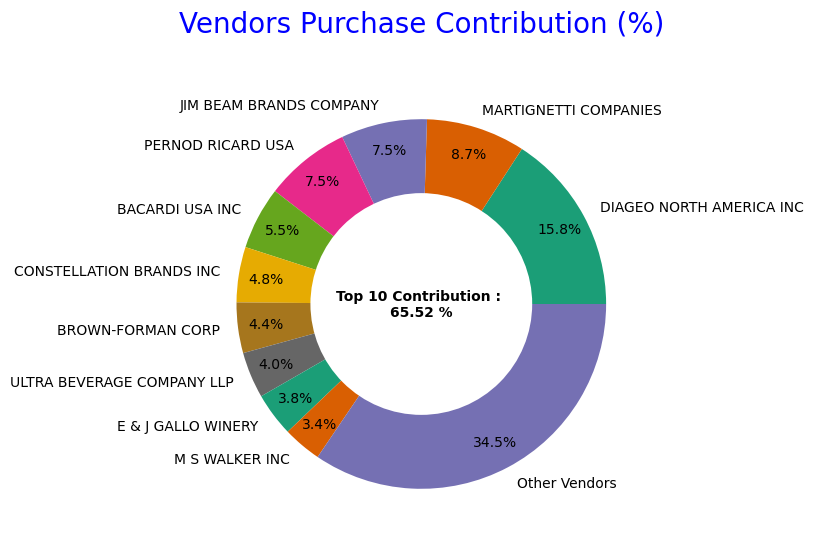

In [17]:
# Pie Chart for better visualization

top_contri = vendor_purchase['PurchaseContribution'].sum()
other_contri = 100 - top_contri

contri_labels = vendor_purchase['VendorName'].to_list()
contri_labels.append('Other Vendors')

contri_values = vendor_purchase['PurchaseContribution'].to_list()
contri_values.append(other_contri)

fig=plt.figure(figsize=(6,6))
plt.pie(contri_values,labels=contri_labels,autopct='%1.1f%%',pctdistance=0.85,colors=plt.cm.Dark2.colors)

fig.gca().add_artist(plt.Circle((0,0),0.6,fc='white'))

plt.text(0,0,f'Top 10 Contribution : \n{top_contri} %', fontweight='bold',ha='center',va='center')

plt.title('Vendors Purchase Contribution (%)',color='blue', fontsize=20, pad=30)
plt.show()

> - Procurement spending is heavily concentrated among a small set of vendors, indicating strong dependency on key suppliers.These vendors play a critical role in supply continuity, making them strategically important for procurement planning.

> - Strong reliance may also reduce negotiation power, as these vendors hold greater influence over pricing.Diversifying the vendor base or strengthening alternative suppliers can help mitigate this procurement risk.

#### Identify target Vendors for Procurement expansion

- i.e. Vendors which provide high profit margin and have strong demand fundamentals but currently allocated low procurement.

In [18]:
high_margin = 30
low_purchase = vendor_summary['TotalPurchaseDollars'].median()
high_sellthrough = 0.75

target_vendors = vendor_summary[(vendor_summary['TotalPurchaseDollars'] <= low_purchase) &
                                (vendor_summary['GrossProfitMargin'] >= high_margin) &
                                (vendor_summary['SellThroughRatio'] >= high_sellthrough)].reset_index(drop=True)

print("Vendors with low procurement but give high profit margin and have strong demand fundamentals :")
display(target_vendors[['VendorName','TotalPurchaseDollars','GrossProfitMargin','SellThroughRatio']].round(2))

Vendors with low procurement but give high profit margin and have strong demand fundamentals :


,VendorName,TotalPurchaseDollars,GrossProfitMargin,SellThroughRatio
0,BRONCO WINE COMPANY,2071.90,32.47,0.77
1,BLACK ROCK SPIRITS LLC,1152.10,43.78,1.00
2,SOUTHERN GLAZERS W&S OF NE,40803.92,32.67,0.78
3,KLIN SPIRITS LLC,103484.29,33.42,0.86
4,MILTONS DISTRIBUTING CO,1577.76,33.63,0.90
5,"PREMIUM PORT WINES, INC.",59760.74,31.85,0.84
6,SURVILLE ENTERPRISES CORP,51187.18,35.13,0.81
7,STELLAR IMPORTING CO LLC,24404.32,35.22,0.80
8,SILVER MOUNTAIN CIDERS,77.18,35.05,1.00
9,POVERTY LANE ORCHARDS,45269.01,33.59,0.87


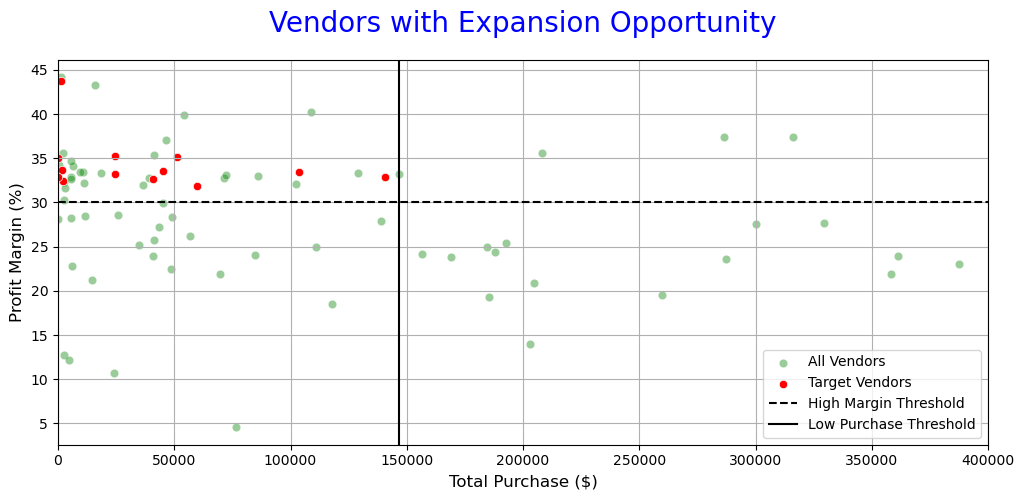

In [19]:
plt.figure(figsize=(12,5))
sns.scatterplot(data= vendor_summary, x='TotalPurchaseDollars',y='GrossProfitMargin',
                label= 'All Vendors',color='green',alpha=0.4)
sns.scatterplot(data= target_vendors, x='TotalPurchaseDollars',y='GrossProfitMargin',
                label= 'Target Vendors',color='red')

plt.axhline(y=high_margin, color='black', linestyle='--', label='High Margin Threshold')
plt.axvline(x=low_purchase, color='black', linestyle='-', label='Low Purchase Threshold')

plt.xlim(0,400_000)
plt.grid(True)
plt.legend()
plt.xlabel('Total Purchase ($)', fontsize=12)
plt.ylabel('Profit Margin (%)', fontsize=12)
plt.title('Vendors with Expansion Opportunity',color='blue',fontsize = 20, pad=20)
plt.show()

> - Vendors with low purchase but high margins represent high-efficiency opportunities that are currently underutilized.  

> - Increasing procurement from such vendors can optimize cost efficiency .Prioritizing them in procurement and promotion strategies can enhance profitability while balancing dependency on major vendors.

#### Comparison of profit margins across high and low sales-performing vendors.  

- High Performance - Top 25% Vendors by total sales.
- Low Performance  - Bottom 25% Vendors by total sales.

In [20]:
vendor_summary[['TotalSalesDollars','GrossProfitMargin']].corr()

,TotalSalesDollars,GrossProfitMargin
TotalSalesDollars,1.000000,0.033295
GrossProfitMargin,0.033295,1.000000


In [21]:
upper_threshold = vendor_summary['TotalSalesDollars'].quantile(0.75)
lower_threshold = vendor_summary['TotalSalesDollars'].quantile(0.25)

# high performing vendors
high_vendors=vendor_summary[vendor_summary['TotalSalesDollars'] >= upper_threshold][
                ['VendorName','GrossProfitMargin']]
# low performing vendors
low_vendors=vendor_summary[vendor_summary['TotalSalesDollars'] <= lower_threshold][
                ['VendorName','GrossProfitMargin']]

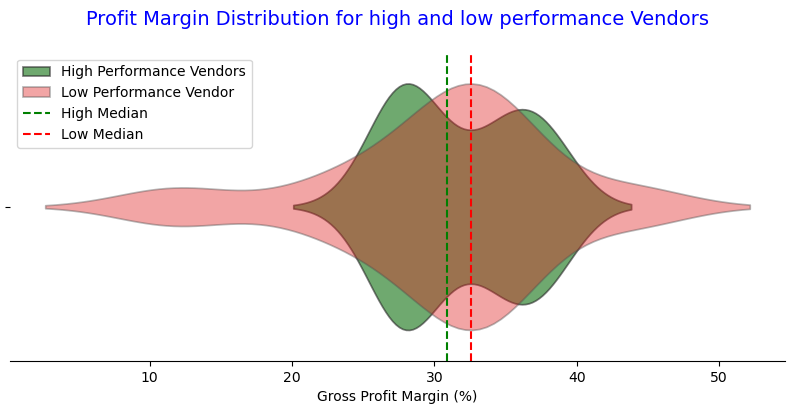

In [22]:
plt.figure(figsize=(10,4))

sns.violinplot(x=high_vendors['GrossProfitMargin'], color='green',alpha=0.6,
               inner=None,label ='High Performance Vendors')
sns.violinplot(x=low_vendors['GrossProfitMargin'], color='red',alpha=0.4,
               inner=None ,label='Low Performance Vendor')
plt.axvline(high_vendors['GrossProfitMargin'].median(),color='green',linestyle='--', label='High Median')
plt.axvline(low_vendors['GrossProfitMargin'].median(),color='red',linestyle='--', label='Low Median')

plt.title('Profit Margin Distribution for high and low performance Vendors', color='blue', fontsize=14, pad=20)
plt.xlabel('Gross Profit Margin (%)')
sns.despine(left='True')
plt.legend()
plt.show()

##### Hypothesis testing (two sample t-test)

H_0 : There is no significant difference in profit margins between high and low performing vendors.  
H_1 : There is significant difference in profit margins between high and low performing vendors. 

In [58]:
t_stat, p_value = stats.ttest_ind(high_vendors['GrossProfitMargin'],low_vendors['GrossProfitMargin'],equal_var=False)
print(f'T-Statistic: {t_stat:.2f} ,P-Value: {p_value:.4f}')

if p_value < 0.05 :
    print('Reject H_0 : There is significant difference in profit margins between high and low performing vendors.')
else:
    print('Fail to Reject H_0 : There is no significant difference in profit margins ' \
    'between high and low performing vendors.')

T-Statistic: 0.89 ,P-Value: 0.3756
Fail to Reject H_0 : There is no significant difference in profit margins between high and low performing vendors.


> - The statistical test fails to reject the null hypothesis, indicating no significant difference in profit margins between high sales and low sales vendors.  

> - Profitability appears to be consistent across vendors regardless of their sales scale, pointing to standardized pricing, highlighting the need for targeted margin optimization initiatives.

#### Vendor Priority Segmentation for strategic decision-making  
Strategic vendor prioritization based on demand ,margin, sell-through, and inventory efficiency

- Vendor Efficiency Index Calculation (VEI)  (*used for segmentation*)  
VEI =0.3*(Revenue Score) + 0.3*(Gross Margin Score) + 0.2*(Sell Through Ratio Score) + 0.2*(1 -Unsold Inventory Score)

- Vendor Segmentation :  
   -Strategic : Strengthen partnerships and scale procurement to maximize revenue.  
   -Optimize : Improve efficiency through better inventory planning, pricing adjustments, and supply alignment.  
   -At Risk : Tightening procurement, addressing inefficiencies, or phasing out.

In [23]:
# Function for min-max normalization
def normalized_score(data) :
    x_min = data.min()
    x_max = data.max()
    score = (data-x_min) / (x_max-x_min)
    return score

In [24]:
# Unsold Inventory Value= Beginning Inventory + Inventory Purchased during period - Inventory Sold during period
vendor_summary['UnsoldInventoryValue'] = (vendor_summary['TotalQuantityPurchased'] + vendor_summary['BeginningInv'] - 
                                          vendor_summary['TotalQuantitySold']) * vendor_summary['PurchasePrice']

# Normalised Score
vendor_summary['RevenueScore'] = normalized_score(vendor_summary['TotalSalesDollars'])
vendor_summary['SellThroughScore'] = normalized_score(vendor_summary['SellThroughRatio'])
vendor_summary['ProfitMarginScore'] = normalized_score(vendor_summary['GrossProfitMargin'])
vendor_summary['InventoryScore'] = 1 - normalized_score(vendor_summary['UnsoldInventoryValue'])

# VEI Score
vendor_summary['VEI'] = (.3*vendor_summary['RevenueScore']+
                         0.3*vendor_summary['ProfitMarginScore'] +
                         0.2*vendor_summary['SellThroughScore'] +
                         0.2*vendor_summary['InventoryScore'])

# Vendor Segmentation based on VEI
vendor_summary['PrioritySegment'] = pd.qcut(vendor_summary['VEI'], q=[0,0.3,0.7,1], 
                                          labels=['At-Risk','Optimize','Strategic'])

vendor_summary['PrioritySegment'].value_counts().reset_index(name ='No_of_Vendors')

,PrioritySegment,No_of_Vendors
0,Optimize,49
1,At-Risk,38
2,Strategic,38


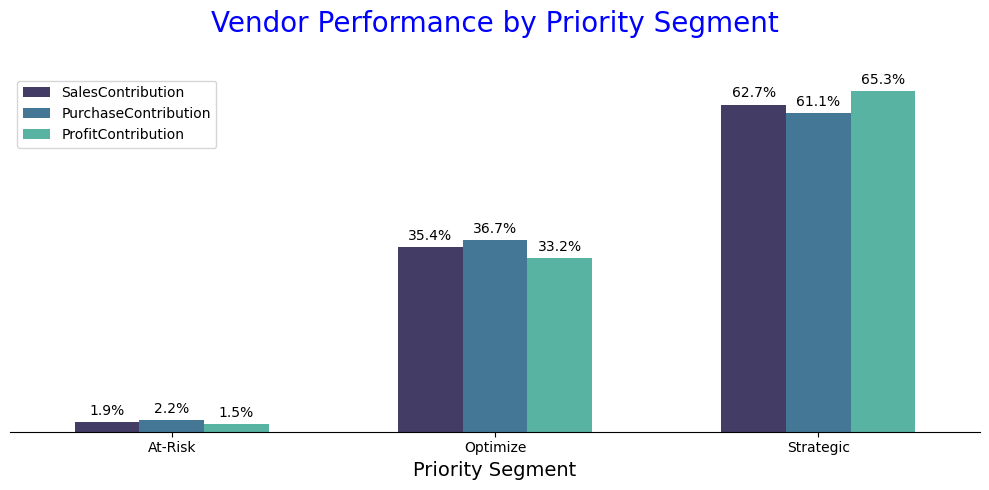

In [25]:
# Revenue, Procurement and Profit Share per Segment
grouped_segment = vendor_summary.groupby('PrioritySegment',observed=False)[
                        ['SalesContribution','PurchaseContribution','ProfitContribution']
                        ].sum().reset_index()

grouped_segment=grouped_segment.melt( id_vars='PrioritySegment',
                    value_vars=['SalesContribution','PurchaseContribution','ProfitContribution'],
                    var_name='Metric',value_name='Contribution')

plt.figure(figsize=(10, 5))

ax = sns.barplot(data=grouped_segment, x='PrioritySegment', y='Contribution',
                  hue='Metric', palette='mako', width=0.6)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Vendor Performance by Priority Segment', color='blue', fontsize=20, pad =30)
plt.xlabel('Priority Segment', fontsize=14)
plt.ylabel('')
plt.legend()
plt.yticks([])

sns.despine(left=True)
plt.tight_layout()
plt.show()

> - The Strategic segment dominates performance, contributing ~ 60% across sales, purchase, and profit, indicating that a small group of highly efficient vendors drives the core business.

> - The Optimize segment shows balanced but moderate contribution, suggesting stable vendors with potential to be scaled into strategic through targeted improvements.

> - The At-Risk segment hold meaningful business share, making them important targets for optimization, by reviewing  margin inefficiencies, cost issues, or inconsistent performance , rather than immediate elimination.

> - Overall, the vendor base is skewed toward a high-performing core with a long tail of less efficient vendors, highlighting opportunities for portfolio optimization and risk reduction.

# Key Insights

#### 1. Business is highly dependent on a limited set of vendors
A small group of vendors drives the majority of sales and profit, creating concentration risk and over-reliance on key partners.
#### 2. Procurement strategy is concentrated but not fully optimized
While procurement is focused on top vendors, there exist underutilized vendors with potential, indicating scope to rebalance sourcing and reduce dependency.
#### 3. High sales do not translate into higher profitability
No significant margin difference across vendor segments suggests that revenue leaders are not necessarily more profitable, highlighting an opportunity to optimize vendor mix beyond just volume.
#### 4. Vendor portfolio impact on business performance and risk exposure
- **Strategic vendors dominate, but over-dependence risk exists.**  
Strategic vendors contribute ~60–64% across sales, profit, and procurement, reinforcing their importance but also signaling risk from heavy reliance on a narrow base.
- **Optimize segment presents a clear opportunity for improvement.**  
With ~30–35% contribution, these vendors have strong business impact but untapped efficiency, making them ideal candidates for performance and procurement optimization.
- **At-risk vendors, though small, are not negligible.**  
Contributing ~3–4%, these vendors still hold meaningful value, and require targeted actions (revive or rationalize) rather than being ignored.

---